In [2]:
# imports
import numpy as np
import matplotlib.pyplot as plt
from mandelbrot_map import diverge_when

plt.rcParams.update({'font.size': 16})

In [ ]:
# PART 1

# helper function
def combine(real, imag):
    """
    This function takes the real part and the imaginary part of a complex number and combines them into the whole complex number.
    
    Parameters:
    real, float array-like, the real part of the complex number
    imag, float array-like, the imaginary part of the complex number
    
    Returns:
    c_num, complex array-like, the whole complex number
    """
    
    return real + imag * 1j

In [ ]:
# set up the grid
real = np.linspace(-2, 2, 500)
imag = np.linspace(-2, 2, 500)
real_grid, imag_grid = np.meshgrid(real, imag)
complex_grid = combine(real_grid, imag_grid)

In [ ]:
# find divergence of each complex point
diverge_result = np.zeros(complex_grid.shape)
binary_diverge = np.ones(complex_grid.shape) #if diverges, 1; if converges, 0

for i in range(0,len(complex_grid)):
    for j in range(0,len(complex_grid[0])):
        diverge_result[i][j] = diverge_when(complex_grid[i][j])
        if np.isnan(diverge_result[i][j]):
            binary_diverge[i][j] = 0

In [ ]:
# plot whether each point diverges or converges
plt.figure(figsize=(8, 8), dpi=80)
plt.pcolormesh(real_grid, imag_grid, binary_diverge, cmap='Accent')
plt.xlabel('Re(z)')
plt.ylabel('Im(z)')
plt.show()

In [ ]:
# plot by how fast each point diverges
plt.figure(figsize=(8, 8), dpi=80)
plt.pcolormesh(real_grid, imag_grid, diverge_result, cmap='summer')
plt.xlabel('Re(z)')
plt.ylabel('Im(z)')
plt.show()

In [3]:
# PART 2

from scipy.integrate import solve_ivp
from lorenz_eqns import lorenz

In [52]:
# solving the equations
t_span = (0,60) #t0 and tfinal
t_eval = np.linspace(0,60,3000)
dt = t_eval[1] - t_eval[0]
w0 = [0,1.0,0] #initial conditions
sigma, r, b = 10, 28, 8/3

sol = solve_ivp(lorenz, t_span, w0, t_eval=t_eval, args=[sigma, r, b], dense_output=True)

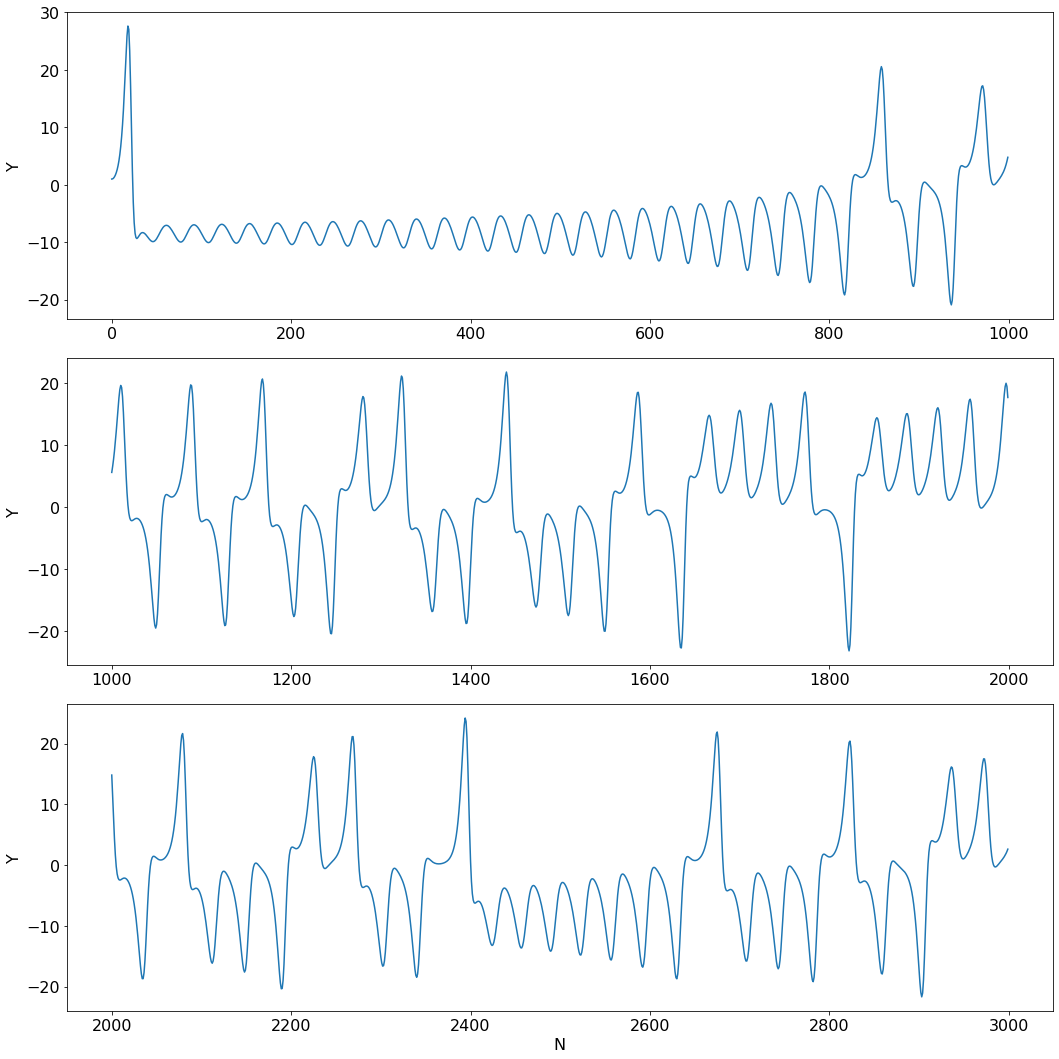

In [38]:
# Lorenz' Figure 1
plt.figure(figsize=(15,15))
plt.subplot(3,1,1)
plt.plot(sol.t[:1000]/dt, sol.y[1][:1000])
plt.ylabel('Y')

plt.subplot(3,1,2)
plt.plot(sol.t[1000:2000]/dt, sol.y[1][1000:2000])
plt.ylabel('Y')

plt.subplot(3,1,3)
plt.plot(sol.t[2000:]/dt, sol.y[1][2000:])
plt.xlabel('N')
plt.ylabel('Y')

plt.tight_layout()

In [33]:
# Lorenz' Figure 2
t_dense = np.linspace(14,19,1001)
w_dense = sol.sol(t_dense)

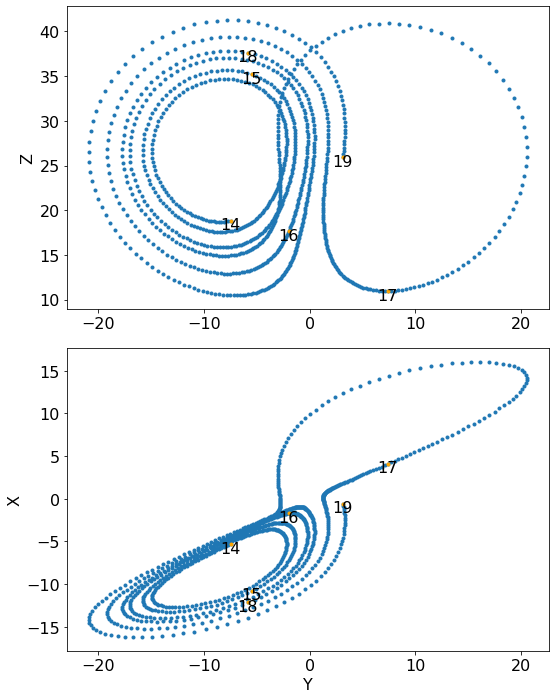

In [37]:
plt.figure(figsize=(8,10))
plt.subplot(2,1,1)
plt.scatter(w_dense[1], w_dense[2], marker='.')
for i in range(14,20):
    x = w_dense[1][(i - 14)*200]
    y = w_dense[2][(i - 14)*200]
    plt.scatter(x, y, marker='.', color='orange')
    plt.text(x-1, y-1, i)
plt.ylabel('Z')

plt.subplot(2,1,2)
plt.scatter(w_dense[1], w_dense[0], marker='.')
for i in range(14,20):
    x = w_dense[1][(i - 14)*200]
    y = w_dense[0][(i - 14)*200]
    plt.scatter(x, y, marker='.', color='orange')
    plt.text(x-1, y-1, i)
plt.xlabel('Y')
plt.ylabel('X')

plt.tight_layout()

In [55]:
# different initial values and looking at deviation
epsilon = [0, 1e-8, 0]
w_prime = [x + y for x, y in zip(w0, epsilon)]
sol_deviate = solve_ivp(lorenz, t_span, w_prime, t_eval=t_eval, args=[sigma, r, b])
#w_prime

In [46]:
# helper function
def distance(r, r_p):
    """
    Function finds distance between two points, r and r_p.
    
    Parameters:
    r, array-like, the first point.
    r_p, array-like, the second point.
    
    Returns:
    d, the distance between the two points.
    """
    
    dists = [np.abs(x - y) for x, y in zip(r, r_p)]
    d = np.sqrt(np.sum(np.power(dists, 2)))
    
    return d

In [63]:
distances = [distance(r1, r2) for r1, r2 in zip(sol.y.T, sol_deviate.y.T)]

Text(0, 0.5, '$|W-W\\prime|$')

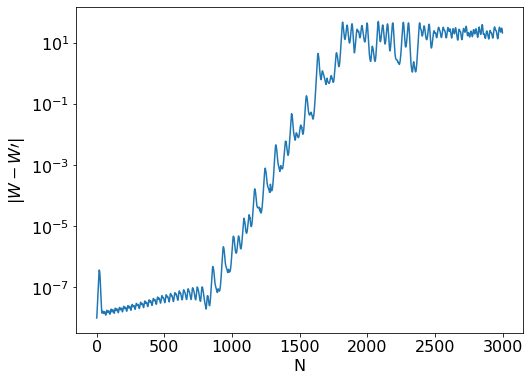

In [68]:
# plotting deviation
plt.figure(figsize=(8,6))
plt.plot(t_eval/dt, distances)
plt.yscale('log')
plt.xlabel('N')
plt.ylabel(r'$|W-W\prime|$')